# 07 自动求导

**向量链式法则**

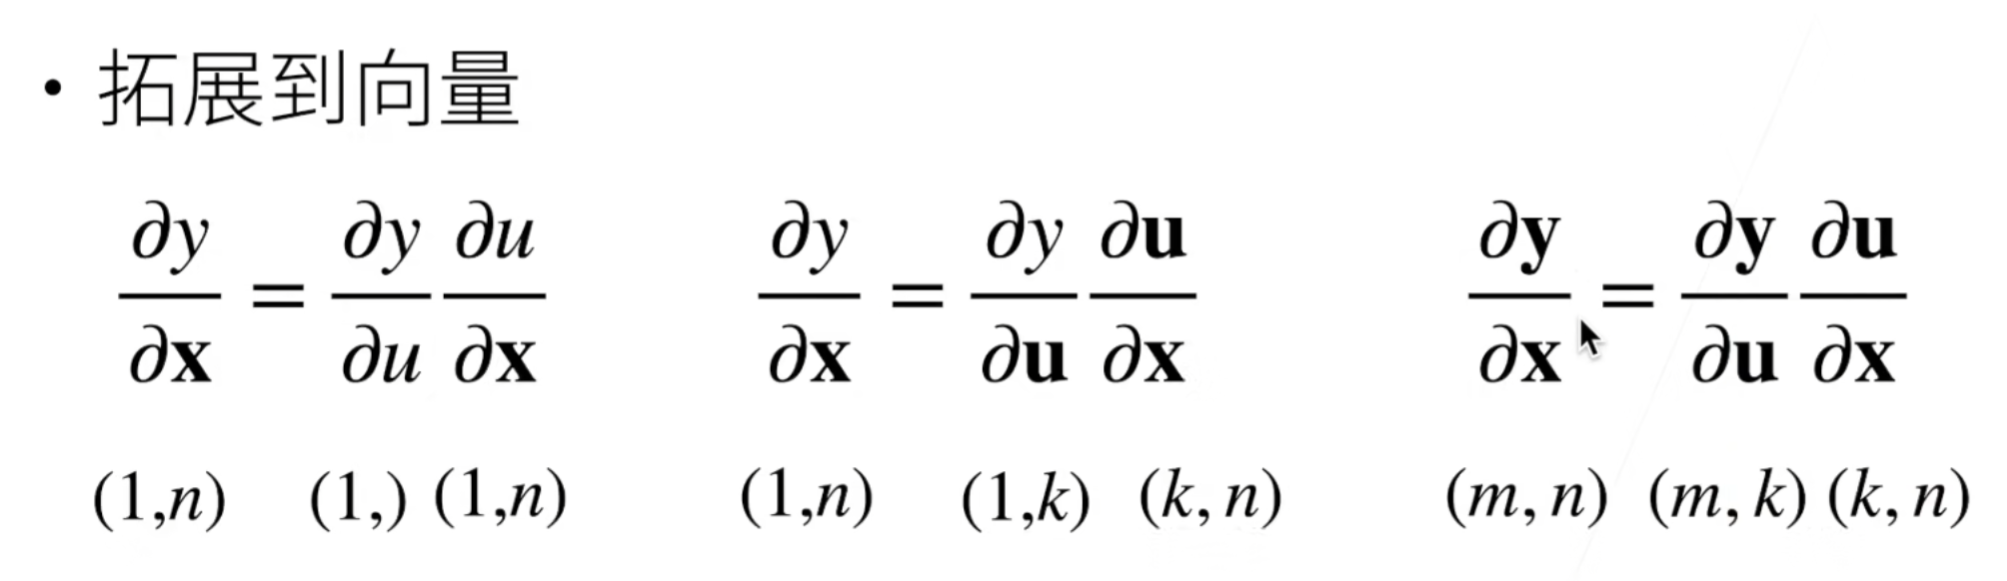

+ identity matrix 是单位矩阵，是一个 n*n 的方阵，对角线为 1，其他元素都为 0

自动求导计算一个函数在指定值上的导数，它与符号求导和数值求导不同

自动求导的两种模式：

1. 链式法则：

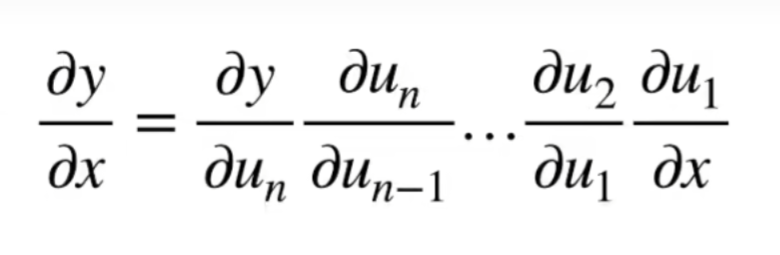

2. 正向累积：

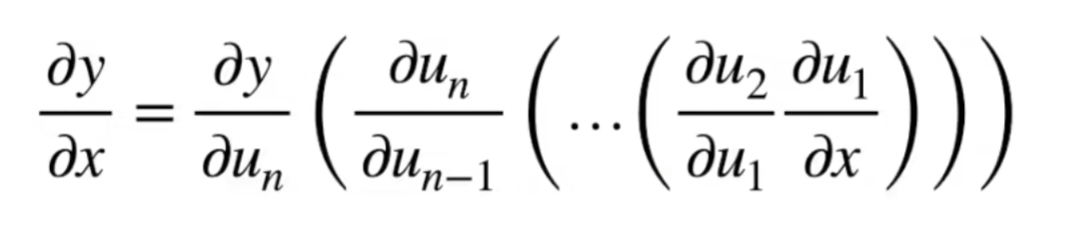

3. 反向累计 / 反向传递

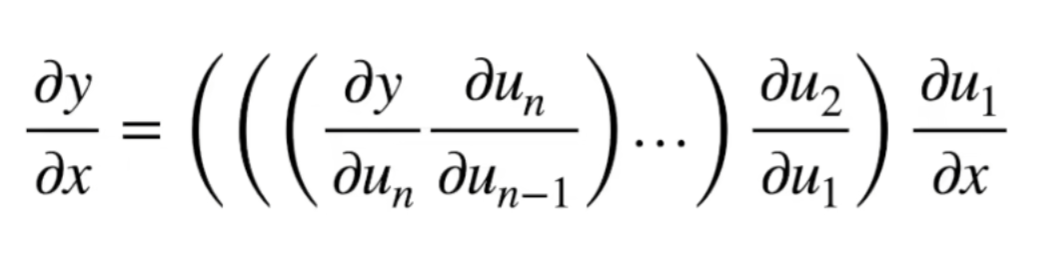

+ 反向传递示意图：读取前面的结果然后再依次求导

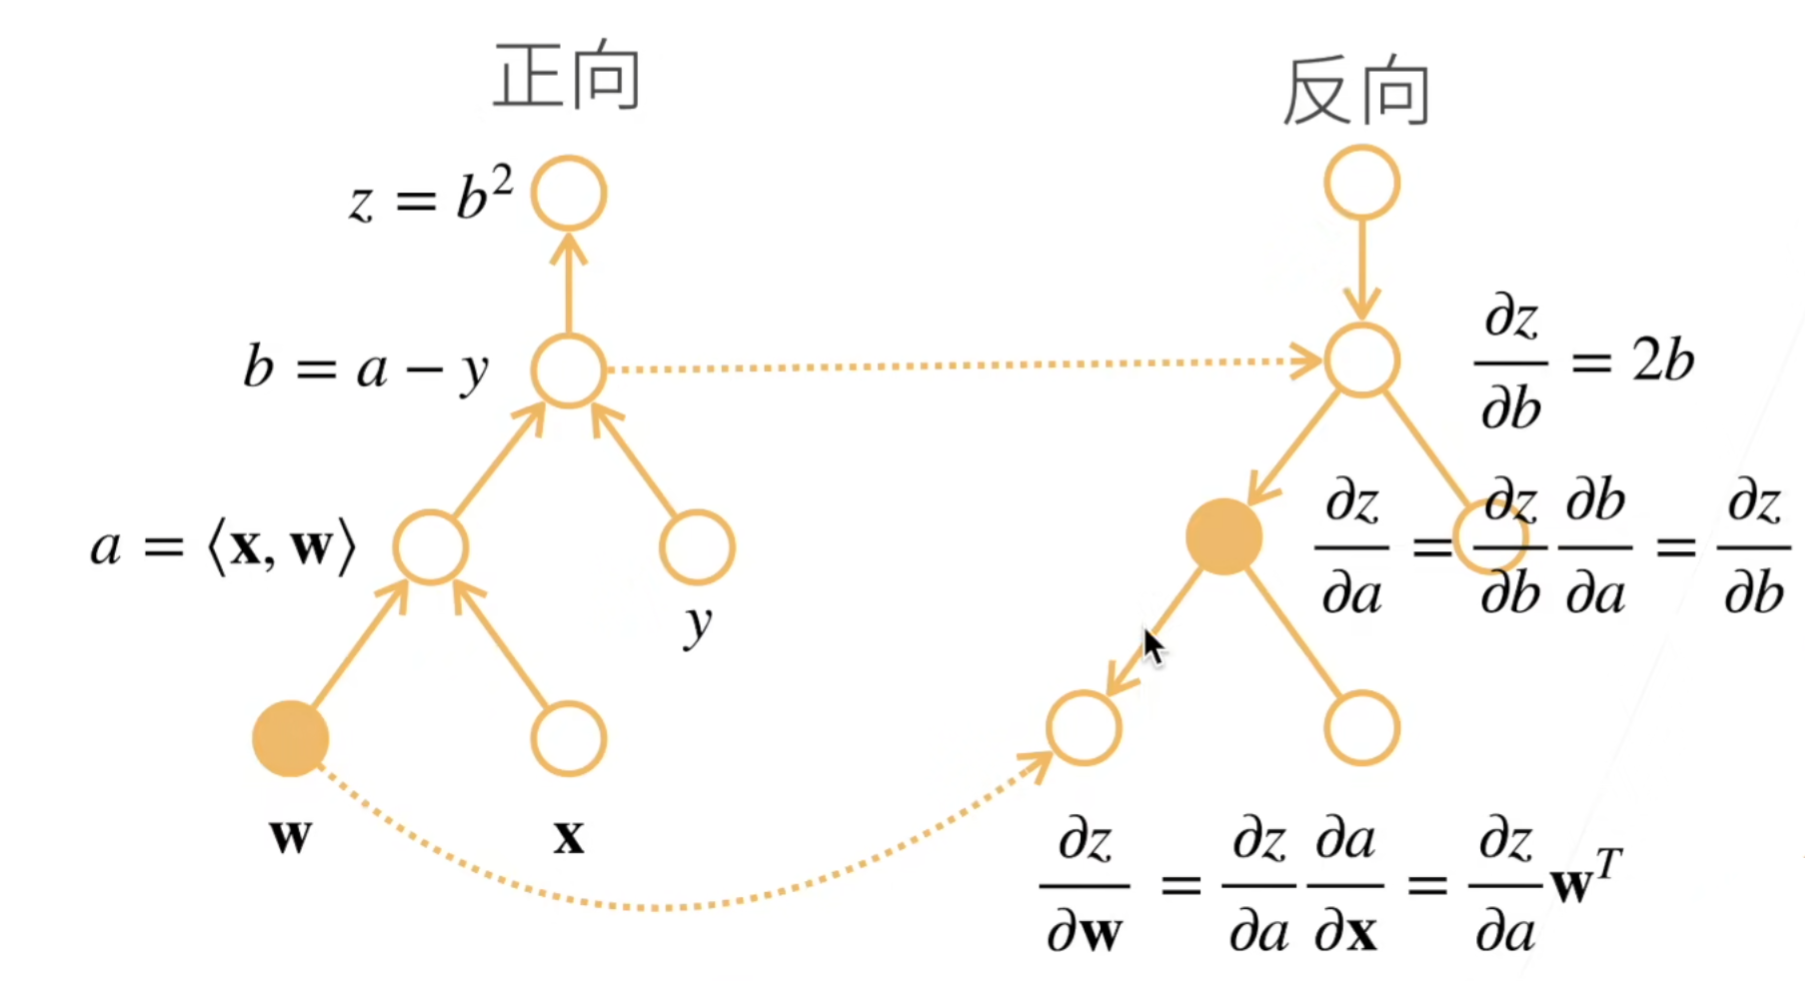

正向传递是从w和x依次往前传递；
反向传递时是先读取之前的结果（z对b求偏导），同样的再往下算出z关于a的偏导，最后再算z关于w的偏导（这里就既需要知道z关于a的偏导又需要知道w的值）
+ 正向是推导，反向是递归

**反向传播-总结**

1. 构造计算图
2. 前向：执行图，并存储中间结果
3. 后向：从相反的方向执行图
   + 去除不需要的枝

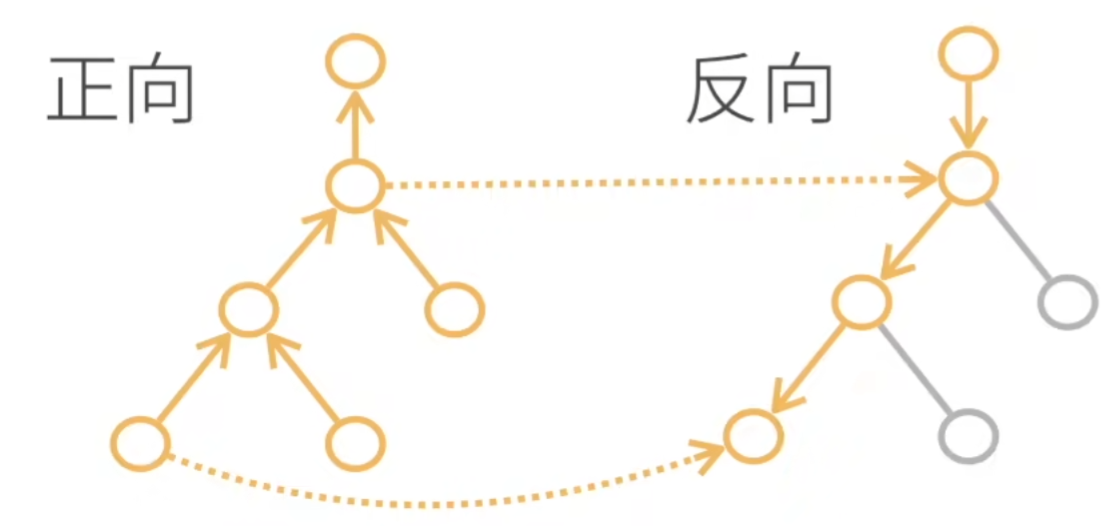

# 自动求导-实现

假设我们想对函数 y=2 xTx 关于列向量x求导:
首先，我们创建变量x并为其分配一个初始值。

In [18]:
import torch 

x=torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

在计算y关于x的梯度之前，我们需要一个地方去存储梯度

In [19]:
x.requires_grad_(True)   #等价于x=torch.arange(4.0,requires_grad=True)
x.grad   #默认值是None  
# 以后可以通过x.grad来访问其梯度

现在开始计算y

In [20]:
y = 2*torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

通过调用反向传播函数来自动计算y关于x每个分量的梯度

In [21]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [23]:
x.grad==4*x
#验证y对x求导的结果

tensor([True, True, True, True])

In [26]:
# 在默认情况下，pytorch 会累计梯度，我们需要清除之前的值
x.grad.zero_() #通过zero函数清零
y=x.sum()
y.backward()
x.grad

tensor([1., 1., 1., 1.])

**对于非标量的反向传播：**
当y不是标量时，向量y关于向量x的导数的最自然解释是一个矩阵；
对于高阶和高维的y和x，求导的结果可以是一个高阶张量

在深度学习中，我们的目的不是计算微分矩阵，而是批量中每个样本单独计算的偏导数之和

In [30]:
# 对非标量调用 backward 需要传入一个 gradient 参数，该参数指定微分函数关于 self 的梯度。
# 本例只想求偏导数的和，所以传递一个 1 的梯度是合适的
x.grad.zero_()
y=x*x
# 等价于 y.backward(torch.ones(len(x)))
y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

**分离计算：** 将某些计算移动到记录的计算图之外

In [33]:
x.grad.zero_()
y=x*x
u=y.detach() # 相当于 把y当作一个常数 而不是关于x的函数
z=u*x

z.sum().backward()
x.grad==u

tensor([True, True, True, True])

In [34]:
#对比一下直接对y
x.grad.zero_()
y.sum().backward()
x.grad==2*x

tensor([True, True, True, True])

**Python控制流的梯度计算：** 即使构建函数的计算图需要通过python的控制流（如：条件、循环、函数调用等），我们仍然可以计算得到的变量的梯度

In [43]:
def f(a):
    b=a*2
    while b.norm()<1000: # b.norm() 是求b的绝对值
        b=b*2
    if b.sum() > 0:
        c=b
    else:
        c=100*b
    return c

a=torch.randn(size=(),requires_grad=True)
d=f(a)
d.backward()

a.grad==d/a

tensor(True)

pytorch的隐式构造的方法相对于其他的来说会很方便，但是代价是其运算起来会相对慢一些